<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/iui2026-xai/Concept_based_xai_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blockies Dataset

This notebook download the blockies dataset and the corresponding trained model.  This is then used to evaluate the model on all datasets.  

Additionally, we provide a review of the various Blocky traits, to review the distributions between ill and healthy Blockies.

In [1]:
import os
from pathlib import Path
import tarfile
import random

import zipfile

import numpy as np

import pandas as pd

from sklearn.metrics import r2_score
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
torch.backends.cudnn.benchmark = True

In [2]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18_regression'

regression_target_columns = [
    'main_spherical', 'sec_spherical', 'bending',  'arm_position',
    'num_sec_bones', 'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw',
    'position_x', 'position_y',
    'obj_color', 'bg_color',
    ]

ds = 'main_blockies/default'
eval_ds = 'main_blockies/highvar'

random_state = 42

output_folder = Path('output/xai_samples/concept_based2')
(output_folder / 'tmp').mkdir(parents=True, exist_ok=True)
(output_folder / 'main_data').mkdir(parents=True, exist_ok=True)
(output_folder / 'tutorial_data').mkdir(parents=True, exist_ok=True)

In [3]:
readable_names = ['Main Bone Shape', 'Sec. Bone Shape', 'Spine Bend', 'Arm Position',
                  'Num. Sec. Bones', 'Position - Roll', 'Position - Pitch', 'Position - Yaw',
                  'Position - X', 'Position-Y', 'Blocky Color', 'Background Color']
name_map = {col: n for col, n in zip(regression_target_columns, readable_names)}
name_map_pred = {f'{col}_pred': n for col, n in zip(regression_target_columns, readable_names)}

# Setup and Load Datasets

In [4]:
# data downloading and dataset utilities
def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

In [5]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True, dtype={'sec_bones': str})
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()
  df['num_sec_bones'] = df.sec_bones.apply(lambda x: x.count('1'))

  return df

In [6]:
class ImageRegressionDataset(Dataset):
    def __init__(self, df, data_dir, transform=None, target_columns=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform
        self.target_columns = target_columns if target_columns is not None else ['main_spherical', 'sec_spherical', 'bending', 'arm_position']


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        # Load the specified target columns instead of just 'ill'
        targets = self.df.iloc[idx][self.target_columns].values.astype(np.float32)
        targets = torch.tensor(targets)

        if self.transform:
            image = self.transform(image)

        return image, targets

## Load Dataset and Dataloaders


In [7]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [8]:
# download the subset of the Blockies data used for the concept-based XAI study
# includes the study dataset which is the main focus of the study and a tutorial dataset
# used for a brief practice phase before the main study
data_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

data_dir = download_file(url=data_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='data', # change this if not using Colab
                          extract=True,
                          force_download=False,
                          archive_folder=zip_name)
data_dir

File already exists at: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [9]:
# load and preprocess dataframes
main_dir = data_dir / 'main_data/xai_samples'
tutorial_dir = data_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_full_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

study_df_copy = study_df.copy().rename(columns=name_map_pred)

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})


In [10]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

num_workers = 0 # set to 0 due to bug in Jupyter notebook

study_dataset = ImageRegressionDataset(study_df, main_dir, 
                                       transform=transform, target_columns=regression_target_columns)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

tutorial_dataset = ImageRegressionDataset(tutorial_df, tutorial_dir,
                                           transform=transform, target_columns=regression_target_columns)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

In [11]:
# downloads the full Blockies datasets including training, validation, and testing datasets
# (not currently used in this notebook, but useful for reference)
full_data_zip = 'https://uni-bielefeld.sciebo.de/s/yfEHoeqfJq4rK7R/download'
full_data_zip_name = 'blockies_datasets.tar.gz'

full_data_dir = download_file(url=full_data_zip,
                              file_name=full_data_zip_name,
                              cache_dir='./data', # change this if not using Colab
                              extract=True,
                              force_download=False,
                              archive_folder='blockies_datasets')
ds_dir = full_data_dir / ds
print(ds_dir)

File already exists at: ./data/blockies_datasets.tar.gz
Extracting tar.gz file...
File extracted to: ./data
data/blockies_datasets/main_blockies/default


In [12]:
test_df = load_dataframe(ds_dir, 'test')

test_dataset = ImageRegressionDataset(test_df, ds_dir / 'test',
                                      transform=transform, target_columns=regression_target_columns)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

# Model Loading and Evaluation





In [13]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

def load_resnet18_regression(num_targets, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_targets)
  print("Loaded ResNet18")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [14]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device, num_targets):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0

    all_preds = []
    all_labels = []


    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate R-squared for each target
    r2_scores = []
    for i in range(num_targets):
        r2 = r2_score(all_labels[:, i], all_preds[:, i])
        r2_scores.append(r2)

    print(f"Evaluation Loss: {avg_loss:.4f}")
    for i, r2 in enumerate(r2_scores):
        print(f"R-squared for target {i}: {r2:.4f}")
    return all_preds, avg_loss, r2_scores

In [15]:
# download pretrained model checkpoint for concept regression model
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/qpOuSHKCgN31OCO/download',
                                file_name='best_model.pth',
                                cache_dir=f'checkpoint/{modeltype}_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=True)
checkpoint_path

  0%|          | 0.00/42.7M [00:00<?, ?B/s]

File downloaded to: checkpoint/resnet18_regression_checkpoint/best_model.pth


PosixPath('checkpoint/resnet18_regression_checkpoint/best_model.pth')

In [16]:
# Define loss function and optimizer
criterion = nn.MSELoss(reduction='sum')

n_targets = len(regression_target_columns)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Evaluate Model

In [17]:
# load best model and evaluate
model = load_resnet18_regression(n_targets,
                                 pretrained=False,
                                 checkpoint_path=checkpoint_path)
model.to(device)

study_preds, _, _ = evaluate_model(model, study_dataloader, criterion, device, n_targets)
tutorial_preds, _, _ = evaluate_model(model, tutorial_dataloader, criterion, device, n_targets)

Loaded ResNet18
Loaded checkpoint from: checkpoint/resnet18_regression_checkpoint/best_model.pth
Evaluation Loss: 0.3791
R-squared for target 0: 0.9694
R-squared for target 1: 0.8239
R-squared for target 2: 0.7605
R-squared for target 3: 0.5902
R-squared for target 4: 0.7804
R-squared for target 5: 0.1163
R-squared for target 6: 0.9574
R-squared for target 7: 0.9829
R-squared for target 8: 0.7302
R-squared for target 9: 0.8703
R-squared for target 10: 0.9915
R-squared for target 11: 0.9984
Evaluation Loss: 0.0057
R-squared for target 0: 0.9988
R-squared for target 1: 0.9737
R-squared for target 2: 0.9915
R-squared for target 3: 0.9616
R-squared for target 4: 0.9967
R-squared for target 5: -0.1399
R-squared for target 6: 0.9965
R-squared for target 7: 0.9998
R-squared for target 8: 0.9929
R-squared for target 9: 0.9901
R-squared for target 10: 0.9978
R-squared for target 11: 0.9994


In [18]:
# add concept preds to dataframe
study_preds_df = pd.DataFrame(study_preds, columns=regression_target_columns)
tutorial_preds_df = pd.DataFrame(tutorial_preds, columns=regression_target_columns)

new_cols = [f'{f}_pred' for f in regression_target_columns]

### Load the Interpretable Model

In [19]:
import joblib

In [20]:
# this notebook uses an explainable boosting machine (https://interpret.ml/docs/ebm.html) to map from predicted concepts to final illness prediction
ebm_model = download_file(url='https://uni-bielefeld.sciebo.de/s/elbFZKs3PlzVxGK/download',
                          file_name='ebm_model.joblib',
                          cache_dir=f'checkpoint/interpretable', # change this if not using Colab
                          extract=False,
                          force_download=True)
ebm_model

  0%|          | 0.00/20.8M [00:00<?, ?B/s]

File downloaded to: checkpoint/interpretable/ebm_model.joblib


PosixPath('checkpoint/interpretable/ebm_model.joblib')

In [21]:
ebm = joblib.load(ebm_model)

In [22]:
X_study = study_df[new_cols].copy()
X_study = X_study.rename(columns=name_map_pred)

X_tutorial = tutorial_df[new_cols].copy()
X_tutorial = X_tutorial.rename(columns=name_map_pred)

In [23]:
study_preds = ebm.predict(X_study)
tutorial_preds = ebm.predict(X_tutorial)

# model should get 80% accuracy on the study dataset and 60% on the tutorial dataset
ebm.score(X_study, study_df['ill']), ebm.score(X_tutorial, tutorial_df['ill'])

(0.8, 0.6)

In [24]:
# assert that all predictions are the same
assert (study_preds == study_df['pred']).all(), 'Study predictions are incorrect'
assert (tutorial_preds == tutorial_df['pred']).all(), 'Tutorial predictions are incorrect '

print('All predictions for each dataset are equal. This is the correct model')

All predictions for each dataset are equal. This is the correct model


In [25]:
# compute max abs score for normalization later on
exp = ebm.explain_local(study_df_copy[name_map_pred.values()], study_df_copy['ill'])
scores = np.array([exp.data(i)['scores'] for i in range(len(study_df_copy))]).ravel()
max_abs_score = np.max(np.abs(scores.ravel()))

## View the XAI Dataset

In [26]:
test = np.array([np.array(Image.open(p).convert('RGB')) for p in main_dir / study_df['filename']])

In [27]:
def display_images(df, n_rows, n_cols, img_dir, title, random_state=0):
  """ Function to display images in a grid randomly selected from a dataframe of images.

  Args:
    df (pd.DataFrame): dataframe of images
    n_rows (int): number of rows in the grid
    n_cols (int): number of columns in the grid
    title (str): title of the plot
    random_state (int): random state for reproducibility
  """

  if n_rows == 0 and n_cols == 0:
    print(f'Not data to display for Figure - {title}')
    return

  if n_rows * n_cols < len(df):
    df = df.sample(n_rows * n_cols, random_state=random_state)

  figsize = (n_cols * 2, n_rows*2.5)
  print(figsize)

  test_images = np.array([np.array(Image.open(p).convert('RGB')) for p in img_dir / df['filename']]) * 1. / 255
  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = np.array(axes)
  for i, (ax, idx) in enumerate(zip(axes.flat, df.index)):
    ax.imshow(test_images[i])
    ax.set_title(f'True={df.loc[idx]["ill"]} - Pred={df.loc[idx]["pred"]}')
    ax.axis('off')

  fig.suptitle(title)
  fig.tight_layout()

(16, 12.5)


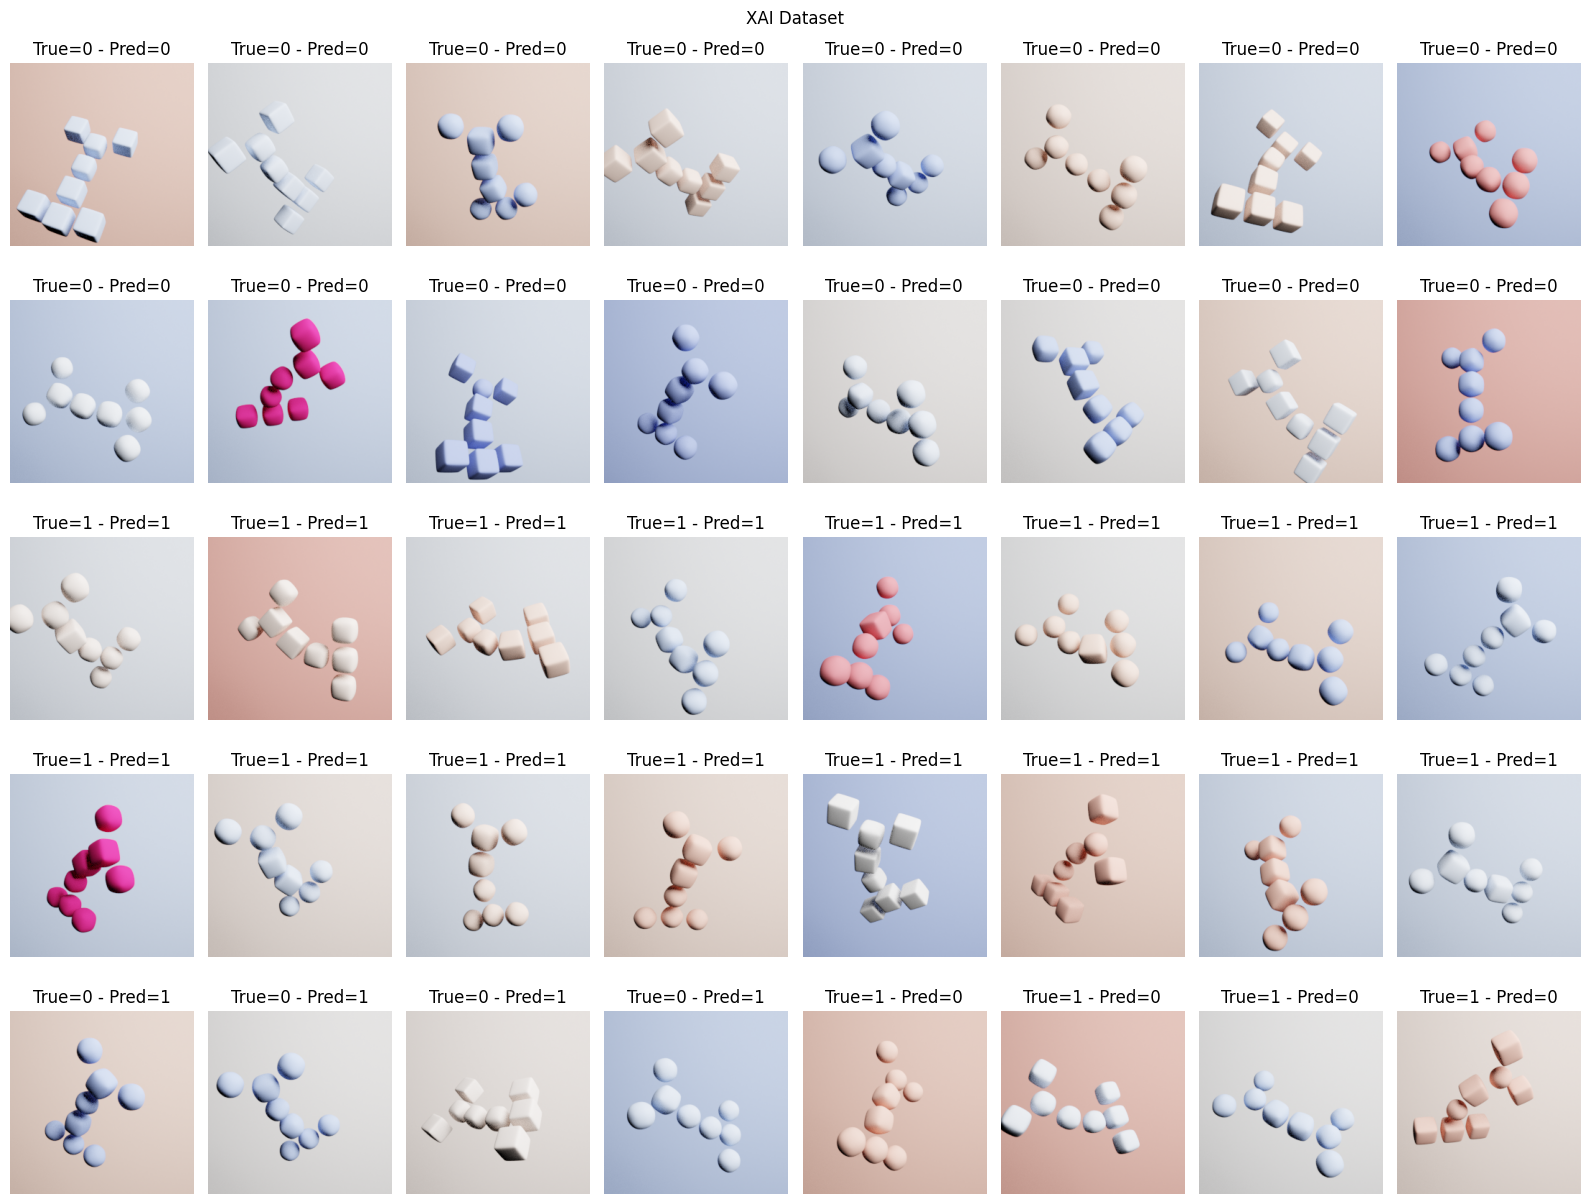

In [28]:
display_images(study_df, 5, 8, main_dir, f'XAI Dataset', random_state=0)

# Generate Explanations

In [29]:
from interpret import show

from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat, EpsilonGammaBox, EpsilonAlpha2Beta1Flat, EpsilonAlpha2Beta1

In [30]:
exp = ebm.explain_local(X_study, study_df['ill'])

In [31]:
import matplotlib as mpl

def combine_and_save(img, attribution, alpha, filter_perc, filename):

    relevance = attribution.sum(0)

    mask_neg = relevance < 0
    neg_rel = abs(relevance) * mask_neg
    thresh_neg = torch.quantile(neg_rel.flatten(), filter_perc)
    mask_neg = neg_rel > thresh_neg

    mask_pos = relevance > 0
    pos_rel = relevance * mask_pos
    thresh_pos = torch.quantile(pos_rel.flatten(), filter_perc)
    mask_pos = pos_rel > thresh_pos

    relevance = relevance * (mask_neg | mask_pos)

    vmax = relevance.abs().max()
    grayscale_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])

    cmap = plt.get_cmap('seismic')
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax, clip=False)
    heatmap_colored = cmap(norm(relevance))[:, :, :3] # Take only RGB channels

    # Convert grayscale image to RGB
    grayscale_rgb = np.stack([grayscale_img] * 3, axis=-1)

    # Combine the grayscale image and the colored heatmap
    # You can adjust the alpha value for the heatmap overlay
    combined_img_np = (grayscale_rgb * (1 - alpha) + heatmap_colored * 255 * alpha).astype(np.uint8)

    # Convert to PIL Image and save
    combined_img_pil = Image.fromarray(combined_img_np)
    combined_img_pil.save(filename)

    return combined_img_pil

In [32]:
def multihot_encode(labels, num_classes):
  """
    Generates a multi-hot encoded tensor from a tuple of labels.

    Args:
        labels (tuple): A tuple of integer labels.
        num_classes (int): The total number of possible classes.

    Returns:
        torch.Tensor: A multi-hot encoded tensor of shape (num_classes,).
    """
  one_hot = torch.zeros(num_classes)
  for label in labels:
    one_hot[label] = 1
  return one_hot

def process_names(name):
  name = name.split(' & ') if '&' in name else [str(name)]
  return name

def calc_and_save_lrp(sample, names, img_dir):

    path = img_dir / sample['filename'].values[0]
    img = Image.open(path).convert('RGB')

    feature_idxs = [tuple(readable_names.index(n) for n in process_names(ns)) for ns in names]

    targets = []
    imgs = []
    for idxs in feature_idxs:
        t = multihot_encode(idxs, len(new_cols))
        targets.append(t)
        imgs.append(img)
    targets = torch.stack(targets)

    inp = [transform(img) for img in imgs]
    inp = torch.stack(inp)
    imgs_np = np.array([np.array(img) for img in imgs])

    with Gradient(model=model, composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attributor:
      inp = inp.to('cpu')
      output, attribution = attributor(inp, targets)

    filenames  = []
    for i, hm in enumerate(attribution):
        filename = f'{sample["id"].values[0]}_lrp_{i}.png'
        path = output_folder / 'tmp' / filename
        img = combine_and_save(imgs_np[i], hm, alpha=.85, filter_perc=.90, filename=path)
        filenames.append(filename)

    return filenames

In [33]:
# setup kmeans for importance score binning for easier user understanding of values
scores_log = np.log(10 + abs(scores)+1e-6)
x = scores_log.reshape(-1, 1)
kmeans = KMeans(n_clusters=4, random_state=0).fit(x)
labels = kmeans.labels_
centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)

def get_bin(x):
    if type(x) is not np.ndarray:
        x = np.array([x])
    x_log = np.log(10 + abs(x) + 1e-6)
    y = kmeans.predict(x_log.reshape(-1, 1))

    label_to_rank = {original_label: rank for rank, original_label in enumerate(order) }

    y_rank = np.array([label_to_rank[label] for label in y])
    return y_rank[0] if len(y_rank) == 1 else y_rank

/Users/djohnson/projects/blockies-xai/.venv/lib/python3.10/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [34]:
# CSV Generation Functions

import random
import ast
import numpy as np
import pandas as pd
import csv

# Class labels
CLASSES = ['Healthy', 'OCDegen']

concept_map = {
    'Main Bone Shape': ["Main Bones: Sharp Cuboids", "Main Bones: Rounded Cuboids", "Main Bones: Blocky Spheres", "Main Bones: Smooth Sphere", "Main Bones Mutation"],
    'Sec. Bone Shape': ["Sec. Bones: Sharp Cuboids", "Sec. Bones: Rounded Cuboids", "Sec. Bones: Blocky Spheres", "Sec. Bones: Smooth Sphere", "Sec. Bones Mutation"],
    'Arm Position': ["Extended Head", "Slightly Extended Head", "Slightly Tucked Head", "Tucked Head"],
    'Bone Shape Variation': ["Low Bone Shape Variation", "Medium-Low Bone Shape Variation", "Medium-High Bone Shape Variation", "High Bone Shape Variation"],
    'Spine Bend': ["Low Spine Bend", "Medium-Low Spine Bend", "Medium-High Spine Bend", "High Spine Bend"],
    'Num. Sec. Bones': ["1 Sec. Bone", "2 Sec. Bones", "3 Sec. Bones", "4 Sec. Bones"],
    'Blocky Color': ["Red Bones", "Reddish-Grey Bones", "Bluish-Grey Bones", "Blue Bones"],
    'Background Color': ["Red Background", "Reddish-Grey Background", "Bluish-Grey Background", "Blue Background"],
    'Position - Roll': ['No Roll', 'Slight Roll', 'Moderate Roll', 'Severe Roll'],
    'Position - Yaw': ['No Yaw', 'Slight Yaw', 'Moderate Yaw', 'Severe Yaw'],
    'Position - Pitch': ['No Pitch', 'Slight Pitch', 'Moderate Pitch', 'Severe Pitch'],
    'Position - X': ['No Horizontal Shift', 'Slight Horizontal Shift', 'Moderate Horizontal Shift', 'Severe Horizontal Shift'],
    'Position - Y': ['No Vertical Shift', 'Slight Vertical Shift', 'Moderate Vertical Shift', 'Severe Vertical Shift'],
    }

ranges = {
    'Main Bone Shape': (0, 1.3),
    'Sec. Bone Shape': (0, 1.3),
    'Arm Position': (0, 1),
    'Bone Shape Variation': (0.1, 0.8),
    'Spine Bend': (0, 0.4),
    'Num. Sec. Bones': (1, 4),
    'Blocky Color': (0, 1),
    'Background Color': (0, 1),
    'Position - Roll': (0, 0.75),
    'Position - Yaw': (0, 0.75),
    'Position - Pitch': (0, 0.75),
    'Position - X': (0, 0.75),
    'Position - Y': (0, 0.75),
}

def discretize_value(value, min_val, max_val, n_bins):
    """
    Discretize a continuous value into one of 4 integer bins (0,1,2,3).

    Parameters:
        value (float): The continuous value to discretize.
        min_val (float): The minimum possible value.
        max_val (float): The maximum possible value.

    Returns:
        int: An integer in [0, 3].
    """
    if max_val == min_val:
        raise ValueError("min_val and max_val must be different")

    # Normalize into [0,1]
    norm = (value - min_val) / (max_val - min_val)
    norm = max(0.0, min(1.0, norm))  # clamp to [0,1]

    # Scale into 4 bins
    return min(n_bins - 1, int(norm * n_bins))


def get_hc_name(concepts, values, include_value=True):
    """
    Returns a two-line caption for Healthy and OCDegen concepts.
    """
    
    if 'Main Bone Shape' in concepts and 'Sec. Bone Shape' in concepts:
        concepts = ['Bone Shape Variation']
        values = [abs(values[0] - values[1])]

    concept_strs = []
    for c, v in zip(concepts, values):
        range = ranges[c]
        n_bins = len(concept_map[c])
        int_val = discretize_value(v, range[0], range[1], n_bins)
        if include_value:
            concept_strs.append(f'{concept_map[c][int_val]} ({v:.2f})')
        else:
            concept_strs.append(f'{concept_map[c][int_val]}')

    return " & ".join(concept_strs)

def get_caption(df_concepts):
    """
    Returns a two-line caption so that CSV viewers
    will show a true line break in the cell.
    """
    concepts = df_concepts["concept"].split(' & ')
    concepts = [c.strip() for c in concepts]

    values = df_concepts["values"]

    concepts_str = get_hc_name(concepts, values)
    
    score = df_concepts["score"]
    score_str = f'Score: {abs(score):.2f} for {"Healthy" if score < 0 else "OCDegen"}'

    return f'{concepts_str}<br>{score_str}'

def get_xray_trait(df, xray_filename):
    matches = df.loc[
        df['filename'] == xray_filename,
        'ill_chars'
    ].values
    if len(matches) == 0:
        return "Unknown"
    ill_raw = matches[0]
    try:
        traits = ast.literal_eval(ill_raw) if isinstance(ill_raw, str) else ill_raw
    except:
        traits = []

    mapped = []
    for trait in traits:
        t = trait.strip()
        if "mutation_color" in t.lower():
            continue
        if t in ["high_bend", "med_bend"] and "Strong Spine Bend" not in mapped:
            mapped.append("Strong Spine Bend")
        elif t in ["high_sphere_diff", "med_sphere_diff"] and "Strong Bone Variation" not in mapped:
            mapped.append("Strong Bone Variation")
        elif t == "mutation_mainbones" and "Main Bones Mutation" not in mapped:
            mapped.append("Main Bones Mutation")
        elif t == "stretchy" and "Tucked Head" not in mapped:
            mapped.append("Tucked Head")
        else:
            mapped.append(t)
    return ", ".join(mapped) if mapped else "No Trait"



In [82]:
sns.set_style("darkgrid")

sns.set_style({
    "axes.facecolor": "0.95",     # light grey background
    "grid.color": "1.0",          # WHITE gridlines
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "axes.edgecolor": (0,0,0,0),  # remove borders
})

def plot_concept_contributions(concepts, filepath, show=False):
    """Plot the concept contributions as a horizontal bar plot."""

    import matplotlib.pyplot as plt
    import seaborn as sns

    fig_height = 0.5 * len(concepts)
    fig = plt.figure(figsize=(8, fig_height))

    # fixed axes: [left, bottom, width, height] in figure coords
    # ax = fig.add_axes([0.3, 0.15, 0.65, 0.75])

    AXES_WIDTH = 0.45   # constant axis width
    RIGHT_MARGIN = 0.03 # small gap on the right

    left = 1 - RIGHT_MARGIN - AXES_WIDTH

    ax = fig.add_axes([left, 0.15, AXES_WIDTH, 0.75])

    sns.barplot(
        x='normed_score',
        y='concept_discrete',
        data=concepts,
        orient='h',
        width=0.6,
        ax=ax
    )

    # color positive/negative bars
    colors = concepts['normed_score'].apply(
        lambda v: '#ee6c4d' if v >= 0 else '#198754'
    ).tolist()

    for patch, c in zip(ax.patches, colors):
        patch.set_color(c)

    ax.set_xlim(-1.05, 1.05)
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Concept Contribution")
    ax.set_ylabel('')

    # custom ticks with no labels
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_xticklabels([])

    # ----- custom Healthy / OCDegen labels -----
    ymin, ymax = ax.get_ylim()
    y_text = ymin - 0.02 * (ymax - ymin)

    ax.text(-0.9, y_text, "To Healthy",
            ha="center", va="top", fontsize=10)
    ax.text(0.86, y_text, "To OCDegen",
            ha="center", va="top", fontsize=10)

    fig.savefig(filepath, dpi=300, bbox_inches=None)
    if show:
        plt.show()
    plt.close(fig)


In [91]:
contributions = ['negligable', 'slight', 'moderate', 'strong']
def concept2text(concept, score):
    n = concept.split(' & ') if '&' in concept else [concept]
    n = [s.strip() for s in n]
    direction = '<span class="unhealthy">OCDegen</span>' if score > 0 else '<span class="healthy">Healthy</span>'
    text = f'<b>{" & ".join(n)}</b> has a <em>{contributions[abs(score)]} contribution</em> to the likelihod of {direction}.'
    return text

def concepts2text(concepts):
    texts = []
    for i, row in concepts.iterrows():
        text = concept2text(row['concept'], row['score_discrete'])
        texts.append(text)
    return texts

In [92]:

def get_top_concepts(sample, feature_cols, target_col, img_dir, n_concepts=3):
    # Get the top concepts from the model

    assert len(sample) == 1, 'Function only handles a single instance'

    exp = ebm.explain_local(sample[feature_cols], sample[target_col])
    sorted_indices = np.argsort(abs(np.array(exp.data(0)['scores'])))
    sorted_indices = sorted_indices[::-1]
    scores = np.array(exp.data(0)['scores'])[sorted_indices]
    names = np.array(exp.data(0)['names'])[sorted_indices]

    values = []
    for n in names[:n_concepts]:
        n = n.split(' & ') if '&' in n else [n]
        n = [s.strip() for s in n]
        v = tuple(sample[s].values[0] for s in n)
        values.append(v)

    # calculate lrp for the top concepts
    filenames = calc_and_save_lrp(sample, names[:n_concepts], img_dir)
    # generate df (cols: lrp filenames, concept names, concept values)
    df = pd.DataFrame({
        'concept': names[:n_concepts],
        'score': scores[:n_concepts],
        'filename': filenames,
        'values': values
    })

    # preprocess data
    df['normed_score'] = df['score'] / max_abs_score
    df['concept_discrete'] = df[['concept', 'values']].apply(
      lambda v: get_hc_name(v['concept'].split(' & '), v['values'], include_value=False),
      axis=1
      )
    df['score_discrete'] = get_bin(df['score'])

    texts = concepts2text(df)
    df['text_description'] = texts
    
    return df

### View Single Example

In [93]:
sample = study_df_copy.sample(n=1, random_state=30)  # example sample
top_concepts = get_top_concepts(sample, feature_cols=name_map_pred.values(), target_col='ill', img_dir=main_dir, n_concepts=5)
top_concepts

,concept,score,filename,values,normed_score,concept_discrete,score_discrete,text_description
0,Spine Bend,3.021350,e91b807f-4d76-4422-a61a-d2731ee93b49_lrp_0.png,"(0.310538,)",0.310734,High Spine Bend,2,<b>Spine Bend</b> has a <em>moderate contribut...
1,Main Bone Shape & Sec. Bone Shape,-2.788632,e91b807f-4d76-4422-a61a-d2731ee93b49_lrp_1.png,"(0.6372122, 0.809752)",-0.286800,Low Bone Shape Variation,2,<b>Main Bone Shape & Sec. Bone Shape</b> has a...
2,Main Bone Shape,-2.319097,e91b807f-4d76-4422-a61a-d2731ee93b49_lrp_2.png,"(0.6372122,)",-0.238510,Main Bones: Blocky Spheres,1,<b>Main Bone Shape</b> has a <em>slight contri...
3,Arm Position,-1.923330,e91b807f-4d76-4422-a61a-d2731ee93b49_lrp_3.png,"(0.32914817,)",-0.197807,Slightly Extended Head,1,<b>Arm Position</b> has a <em>slight contribut...
4,Main Bone Shape & Arm Position,-1.529382,e91b807f-4d76-4422-a61a-d2731ee93b49_lrp_4.png,"(0.6372122, 0.32914817)",-0.157291,Main Bones: Blocky Spheres & Slightly Extended...,1,<b>Main Bone Shape & Arm Position</b> has a <e...


In [94]:
texts = top_concepts['text_description'].tolist()
for t in texts: print(t)

<b>Spine Bend</b> has a <em>moderate contribution</em> to the likelihod of <span class="unhealthy">OCDegen</span>.
<b>Main Bone Shape & Sec. Bone Shape</b> has a <em>moderate contribution</em> to the likelihod of <span class="unhealthy">OCDegen</span>.
<b>Main Bone Shape</b> has a <em>slight contribution</em> to the likelihod of <span class="unhealthy">OCDegen</span>.
<b>Arm Position</b> has a <em>slight contribution</em> to the likelihod of <span class="unhealthy">OCDegen</span>.
<b>Main Bone Shape & Arm Position</b> has a <em>slight contribution</em> to the likelihod of <span class="unhealthy">OCDegen</span>.


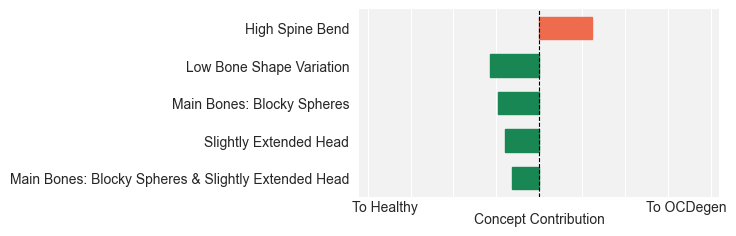

In [95]:
plot_concept_contributions(top_concepts, 'concept_contributions.png', show=True)

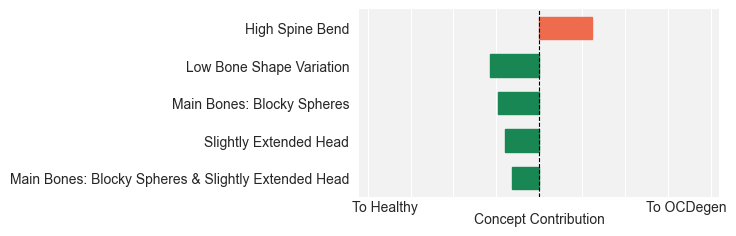

In [96]:
plot_concept_contributions(top_concepts, 'concept_contributions.png', show=True)

### Generate Web Site Data

The following cells generates a CSV file that can be used with the `./db.create.new.study` from the decsion-support web app.  

After running the code you should have a CSV with file details and a Zip file with the final image files needed. Download the files and unzip the images. You can then use the following on command line to setup a 'study' using Blockies web app.

```bash
./db.create.new.study 12 5  < PATH TO CSV > < PATH TO IMAGES >
```

where 12 is a study id (can be any unique integer) and 5 is the ID of the web app template to use (it should always be set to 5 for this XAI type)

In [97]:
def generate_csv(study_df, output_csv_path, img_dir, n_concepts=4):
    
    df = None
    for _, row in study_df.iterrows():
        target_true     = int(row['ill'])
        target_pred     = int(row['pred'])

        top_concepts = get_top_concepts(row.to_frame().T, name_map_pred.values(), 'ill', img_dir, n_concepts=n_concepts)

        new_row = {
            "PATIENT_ID": row['p_id'],
            "X_RAY_IMAGE": row['filename'],
            "TRUE_DIAG": CLASSES[target_true],
            "SUGGESTED_DIAG": CLASSES[target_pred]
        }
        for idx, c in top_concepts.iterrows():
            if idx >= n_concepts:
                break
            new_row[f'Concept{idx+1}_Salience'] = c['filename']
            new_row[f'Concept{idx+1}_Caption'] = get_caption(c)
            new_row[f'Concept{idx+1}_Description'] = c['text_description']

        plot_concept_contributions(top_concepts, output_folder / 'tmp' / f'concepts_{row["id"]}.png', show=False)
        new_row['contribution_plot'] = f'concepts_{row["id"]}.png'
        
        if df is None:
            df = pd.DataFrame([new_row])
        else:
            df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Fill in traits
    df['X_RAY_TRAIT'] = df['X_RAY_IMAGE'].apply(lambda x: get_xray_trait(study_df, x))

    # Random locations
    locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
    df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

    # Refresh INDEX
    if "INDEX" in df.columns:
        df = df.drop(columns=["INDEX"])
    df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

    # Reorder & save with quoting so newlines persist
    df.to_csv(
        # output_folder / "main_data/input_example.csv",
        output_csv_path,
        index=False,
        quoting=csv.QUOTE_ALL
    )
    print(f"Saved {output_csv_path} with captions")

In [ ]:
n_concepts = 5 
study_df_copy = study_df.copy().rename(columns=name_map_pred)
generate_csv(study_df_copy, output_folder / "main_data/input_example.csv", main_dir, n_concepts=n_concepts)

In [ ]:
df

,PATIENT_ID,X_RAY_IMAGE,TRUE_DIAG,SUGGESTED_DIAG,Concept1_Salience,Concept1_Caption,Concept1_Description,Concept2_Salience,Concept2_Caption,Concept2_Description,...,Concept4_Salience,Concept4_Caption,Concept4_Description,Concept5_Salience,Concept5_Caption,Concept5_Description,contribution_plot,X_RAY_TRAIT,X_RAY_LOCATION,INDEX
0,SUXXECT8,3e7da57f-bc60-4f3d-a374-872088e3795e.png,Healthy,Healthy,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_0.png,Main Bones Mutation (1.13)<br>Score: 3.49 for ...,Main Bone Shape has a moderate contribution to...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_1.png,Medium-Low Bone Shape Variation (0.37)<br>Scor...,Main Bone Shape & Sec. Bone Shape has a modera...,...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_3.png,Slightly Extended Head (0.46)<br>Score: 1.83 f...,Arm Position has a slight contribution to the ...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_4.png,Medium-Low Spine Bend (0.18)<br>Score: 1.78 fo...,Spine Bend has a slight contribution to the li...,concepts_3e7da57f-bc60-4f3d-a374-872088e3795e.png,Main Bones Mutation,SF,39
1,E79FKNIX,56591a49-6a14-4b02-8c82-37db171334e2.png,OCDegen,OCDegen,56591a49-6a14-4b02-8c82-37db171334e2_lrp_0.png,Medium-High Bone Shape Variation (0.62)<br>Sco...,Main Bone Shape & Sec. Bone Shape has a strong...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_1.png,Main Bones Mutation (1.13)<br>Score: 3.49 for ...,Main Bone Shape has a moderate contribution to...,...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_3.png,Slightly Extended Head (0.45)<br>Score: 1.87 f...,Arm Position has a slight contribution to the ...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_4.png,Medium-Low Spine Bend (0.17)<br>Score: 1.79 fo...,Spine Bend has a slight contribution to the li...,concepts_56591a49-6a14-4b02-8c82-37db171334e2.png,"Strong Bone Variation, Main Bones Mutation",CHI,19
2,SA9YY388,365a071e-2af3-42ca-ad1f-bf68c306fb99.png,Healthy,Healthy,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_0.png,Medium-Low Bone Shape Variation (0.40)<br>Scor...,Main Bone Shape & Sec. Bone Shape has a strong...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_1.png,Main Bones: Sharp Cuboids (-0.01) & Medium-Low...,Main Bone Shape & Spine Bend has a moderate co...,...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_3.png,Medium-Low Spine Bend (0.12) & Slightly Extend...,Spine Bend & Arm Position has a slight contrib...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_4.png,Medium-Low Spine Bend (0.12)<br>Score: 1.88 fo...,Spine Bend has a slight contribution to the li...,concepts_365a071e-2af3-42ca-ad1f-bf68c306fb99.png,No Trait,DEN,58
3,7OZL28JI,b03b85f7-b156-46b8-aa7e-94684086179a.png,OCDegen,OCDegen,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_0.png,Main Bones Mutation (1.16) & Slightly Tucked H...,Main Bone Shape & Arm Position has a strong co...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_1.png,Main Bones Mutation (1.16)<br>Score: 3.60 for ...,Main Bone Shape has a moderate contribution to...,...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_3.png,Medium-Low Bone Shape Variation (0.37)<br>Scor...,Main Bone Shape & Sec. Bone Shape has a modera...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_4.png,Low Spine Bend (0.04)<br>Score: 1.85 for Healthy,Spine Bend has a slight contribution to the li...,concepts_b03b85f7-b156-46b8-aa7e-94684086179a.png,"Main Bones Mutation, Tucked Head",MIA,43
4,P73UBBO7,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a.png,Healthy,Healthy,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_0.png,Main Bones Mutation (1.18)<br>Score: 3.70 for ...,Main Bone Shape has a moderate contribution to...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_1.png,Low Bone Shape Variation (0.27)<br>Score: 3.60...,Main Bone Shape & Sec. Bone Shape has a modera...,...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_3.png,Slightly Extended Head (0.44)<br>Score: 1.92 f...,Arm Position has a slight contribution to the ...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_4.png,Medium-Low Spine Bend (0.16)<br>Score: 1.88 fo...,Spine Bend has a slight contribution to the li...,concepts_1a51763c-6e4c-4c2f-b4d1-f7be

In [ ]:
#Zipfile
df = pd.read_csv(output_folder / "main_data/input_example.csv")

example_dr = output_folder / 'tmp'  # Added definition for example_dr
zip_filename = output_folder / "main_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
examples_filecols = [c for c in df.columns.tolist() if 'Salience' in c]
print(examples_filecols)
example_files = pd.unique(df[examples_filecols].values.ravel())

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

plots_filecol = ['contribution_plot']
plot_files = pd.unique(df[plots_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = main_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in plot_files:
        img_path = output_folder / 'tmp' / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files) + len(plot_files)} images to {zip_filename}")

['Concept1_Salience', 'Concept2_Salience', 'Concept3_Salience', 'Concept4_Salience', 'Concept5_Salience']
Saved 280 images to output/xai_samples/concept_based2/main_data/study_images_example.zip


### Tutorial Data

In [ ]:
tutorial_df_copy = tutorial_df.copy().rename(columns=name_map_pred)
generate_csv(tutorial_df_copy, output_folder / "tutorial_data/input_example.csv", tutorial_dir, n_concepts=n_concepts)

Saved output/xai_samples/concept_based2/tutorial_data/input_example.csv with captions


In [ ]:
#Zipfile
df = pd.read_csv(output_folder / "tutorial_data/input_example.csv")
example_dr = output_folder / 'tmp' # Added definition for example_dr
zip_filename = output_folder / "tutorial_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
examples_filecols = [c for c in df.columns.tolist() if 'Salience' in c]
example_files = pd.unique(df[examples_filecols].values.ravel())

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

plots_filecol = ['contribution_plot']
plot_files = pd.unique(df[plots_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = tutorial_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in plot_files:
        img_path = output_folder / 'tmp' / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files) + len(plot_files)} images to {zip_filename}")

Saved 140 images to output/xai_samples/concept_based2/tutorial_data/study_images_example.zip
